# 💊 Medicine Name Reconstruction (Kaggle-Ready)

**Produces Test Case output like:**
```
Test Case 1:
Input: panadl
Predicted Output: panadol
Expected Output: panadol
```

## 📋 Steps
| # | Task |
|---|------|
| 0 | Install packages |
| 1 | **Configuration — set DRUGS_LIST path** |
| 2 | Load generic drug names |
| 3 | Generate misspellings |
| 4 | Build training dataset |
| 5 | Vocabulary & encoding |
| 6 | Masked loss + accuracy |
| 7 | Build & train BiLSTM |
| 8 | Evaluate (neural + dataset-snap) |
| 9 | **Test predictions in Test Case format** |
| 10 | Save ALL artifacts to /kaggle/working |
| 11 | Interactive GUI |
| 12 | Reload model (skip retraining) |

> ⚠ **CRITICAL:** All saved files MUST go to `/kaggle/working/` — that's the only folder whose files appear in Kaggle's Output panel for download. `/kaggle/input/` is read-only.


## Step 0 · Install Packages

In [1]:
import sys
!{sys.executable} -m pip install -q tensorflow numpy pandas scikit-learn matplotlib python-Levenshtein ipywidgets
print("✅ Packages ready")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 153.3/153.3 kB 11.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 83.1 MB/s eta 0:00:00:00:01
✅ Packages ready


## Step 1 · Configuration

### ⚠ IMPORTANT: Only change `DRUGS_LIST` path
All output paths must stay as `/kaggle/working/...` — otherwise they won't save!


In [2]:
# ═══════════════════════════════════════════════════════════════════
# 🔧 ONLY CHANGE THIS LINE ↓ to match YOUR Kaggle dataset slug
DRUGS_LIST = '/kaggle/input/datasets/hatsooff/medecinelist/Medecinelist.txt'
# ═══════════════════════════════════════════════════════════════════

# ⚠ Keep these ALL pointing to /kaggle/working/ — so files appear in Output panel
MODEL_PATH = '/kaggle/working/medicine_lstm.keras'
T2I_PATH   = '/kaggle/working/token_to_idx.json'
I2T_PATH   = '/kaggle/working/idx_to_token.json'
CFG_PATH   = '/kaggle/working/model_config.json'
NAMES_PATH = '/kaggle/working/known_names.txt'
PAIRS_CSV  = '/kaggle/working/medicine_pairs.csv'

# Dataset generation
MAX_PAIRS_PER_NAME = 40     # misspellings per drug

# Model
EMBEDDING_DIM = 128
LSTM_UNITS    = 256
DROPOUT       = 0.15
BATCH_SIZE    = 256
MAX_EPOCHS    = 80
PATIENCE      = 12
RANDOM_SEED   = 42

print("✅ Config ready — all saves go to /kaggle/working/")


✅ Config ready — all saves go to /kaggle/working/


## Step 2 · Load Drug Names

In [3]:
import os, re, json, time, pickle, random, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import Levenshtein

import tensorflow as tf
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Embedding, Bidirectional, LSTM, TimeDistributed, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.model_selection import train_test_split

warnings.filterwarnings('ignore')
tf.get_logger().setLevel('ERROR')
random.seed(RANDOM_SEED); np.random.seed(RANDOM_SEED); tf.random.set_seed(RANDOM_SEED)

# Ensure /kaggle/working exists (it does on Kaggle, but be safe)
os.makedirs('/kaggle/working', exist_ok=True)

print(f"TensorFlow : {tf.__version__}")
print(f"GPU        : {bool(tf.config.list_physical_devices('GPU'))}")


2026-04-22 17:17:53.622516: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1776878273.831254      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1776878273.889808      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1776878274.366936      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776878274.366984      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776878274.366987      55 computation_placer.cc:177] computation placer alr

TensorFlow : 2.19.0
GPU        : True


In [4]:
# Load drug names from the uploaded file
with open(DRUGS_LIST, 'r', encoding='utf-8') as f:
    drug_names = sorted(set(line.strip().lower() for line in f if line.strip()))

drug_names = [n for n in drug_names if n.isalpha() and 4 <= len(n) <= 22]

print(f"Total unique drugs : {len(drug_names):,}")
print(f"\nSample:")
for n in random.sample(drug_names, 15): print(f"  {n}")

# Verify target drugs from reference image
print(f"\nTarget drug presence:")
for t in ['panadol','avastin','amlodipine','hydrocodone','morphine',
          'paracetamol','aspirin','ibuprofen','augmentin','azithromycin']:
    print(f"  {t:15} {'✓' if t in drug_names else '✗ MISSING'}")


Total unique drugs : 27,102

Sample:
  clavobid
  alive
  acerest
  cucon
  atpan
  asclavmox
  arduan
  alzolite
  croban
  alenpas
  clozol
  ctwo
  cefurixo
  akilos
  ciaga

Target drug presence:
  panadol         ✓
  avastin         ✓
  amlodipine      ✓
  hydrocodone     ✓
  morphine        ✓
  paracetamol     ✓
  aspirin         ✓
  ibuprofen       ✓
  augmentin       ✓
  azithromycin    ✓


## Step 3 · Generate Misspellings

In [5]:
KEYBOARD = {
    'a':'sqzw','b':'vghn','c':'xdfv','d':'serfcx','e':'wsdr','f':'drtgvc',
    'g':'ftyhbv','h':'gyujnb','i':'ujko','j':'huikm','k':'jiol','l':'kop',
    'm':'njk','n':'bhjm','o':'ikpl','p':'ol','q':'wa','r':'edft','s':'awedxz',
    't':'rfgy','u':'yhji','v':'cfgb','w':'qase','x':'zsdc','y':'tghu','z':'asx',
}

def generate_misspellings(word):
    w = word.lower().strip()
    n = len(w)
    if n < 4: return []
    variants = set()

    for i in range(n):                         # delete
        s = w[:i] + w[i+1:]
        if len(s) >= 3: variants.add(s)
    for i in range(n-1):                       # swap
        lst = list(w); lst[i], lst[i+1] = lst[i+1], lst[i]
        variants.add(''.join(lst))
    for i in range(n):                         # substitute
        for sub in KEYBOARD.get(w[i], ''):
            variants.add(w[:i] + sub + w[i+1:])
    for i in range(n):                         # double
        s = w[:i] + w[i] + w[i:]
        if len(s) <= 26: variants.add(s)
    for d in range(1, min(3, n-3)): variants.add(w[d:])      # drop prefix
    for d in range(1, min(3, n-3)): variants.add(w[:-d])     # drop suffix

    variants.discard(w); variants.discard('')
    return [v for v in variants if len(v) >= 3]

# Demo on image targets
for demo in ['panadol', 'amlodipine', 'morphine']:
    mis = generate_misspellings(demo)
    print(f"'{demo}' → {len(mis)} variants: {sorted(mis)[:5]}...")


'panadol' → 49 variants: ['anadol', 'apnadol', 'lanadol', 'nadol', 'oanadol']...
'amlodipine' → 69 variants: ['aamlodipine', 'ajlodipine', 'aklodipine', 'almodipine', 'alodipine']...
'morphine' → 56 variants: ['jorphine', 'korphine', 'mirphine', 'mkrphine', 'mlrphine']...


## Step 4 · Build Training Dataset

In [6]:
records = []
for correct in drug_names:
    # Include the correct name twice so model learns to keep correct inputs
    records.append((correct, correct))
    records.append((correct, correct))
    variants = generate_misspellings(correct)
    random.shuffle(variants)
    for mis in variants[:MAX_PAIRS_PER_NAME]:
        records.append((mis, correct))

random.shuffle(records)
seen, final = set(), []
for inp, out in records:
    key = (inp.strip(), out.strip())
    if key not in seen and len(inp) >= 3:
        seen.add(key)
        final.append({'Input': inp, 'Output': out})

df = pd.DataFrame(final)
df.to_csv(PAIRS_CSV, index=False)

print(f"✅ Pairs saved → {PAIRS_CSV}")
print(f"   Total pairs          : {len(df):,}")
print(f"   Unique correct names : {df['Output'].nunique():,}")
display(df.sample(10, random_state=1))


✅ Pairs saved → /kaggle/working/medicine_pairs.csv
   Total pairs          : 1,084,300
   Unique correct names : 27,102


,Input,Output
788370,brotik,brotim
259964,cilnic,cilnicen
727535,satus,astus
409225,caudthro,caudithro
265176,defzen,cefzen
339385,ablenum,albenum
294317,cortyzin,cortyzin
753456,acpeshild,capeshild
170184,cdimycetin,cadimycetin
810497,alzrt,alzet


## Step 5 · Vocabulary & Encoding

In [7]:
df = pd.read_csv(PAIRS_CSV)
df['Input']  = df['Input'].astype(str).str.lower().str.strip()
df['Output'] = df['Output'].astype(str).str.lower().str.strip()
df = df.drop_duplicates(subset=['Input','Output']).reset_index(drop=True)

all_chars = set()
for col in ['Input','Output']:
    for w in df[col]: all_chars.update(list(w))

vocab        = ['<EOS>', '<PAD>'] + sorted(all_chars)
token_to_idx = {tok: i for i, tok in enumerate(vocab)}
idx_to_token = {i: tok for tok, i in token_to_idx.items()}
PAD_IDX      = token_to_idx['<PAD>']
EOS_IDX      = token_to_idx['<EOS>']
VOCAB_SIZE   = len(vocab)
MAX_LEN      = int(df['Output'].str.len().quantile(0.99)) + 3

# Save vocab RIGHT NOW to /kaggle/working/
with open(T2I_PATH,'w') as f: json.dump(token_to_idx, f, indent=2)
with open(I2T_PATH,'w') as f: json.dump(idx_to_token, f, indent=2)
print(f"✅ Vocab saved → {T2I_PATH}, {I2T_PATH}")
print(f"   Vocab size : {VOCAB_SIZE}  |  PAD : {PAD_IDX}  |  MAX_LEN : {MAX_LEN}")
print(f"   Characters : {''.join(sorted(all_chars))}")


✅ Vocab saved → /kaggle/working/token_to_idx.json, /kaggle/working/idx_to_token.json
   Vocab size : 28  |  PAD : 1  |  MAX_LEN : 15
   Characters : abcdefghijklmnopqrstuvwxyz


In [8]:
def encode(text):
    return [token_to_idx.get(c, PAD_IDX) for c in list(str(text).lower().strip())]

X = pad_sequences([encode(t) for t in df['Input']],  maxlen=MAX_LEN, padding='post', value=PAD_IDX, truncating='post')
y = pad_sequences([encode(t) for t in df['Output']], maxlen=MAX_LEN, padding='post', value=PAD_IDX, truncating='post')
print(f"X : {X.shape}  y : {y.shape}  RAM : {(X.nbytes+y.nbytes)/1e6:.1f} MB")

X_tmp, X_test, y_tmp, y_test = train_test_split(X, y, test_size=0.10, random_state=RANDOM_SEED, shuffle=True)
X_train, X_val, y_train, y_val = train_test_split(X_tmp, y_tmp, test_size=0.10, random_state=RANDOM_SEED)
print(f"Train:{X_train.shape[0]:,}  Val:{X_val.shape[0]:,}  Test:{X_test.shape[0]:,}")


X : (1084300, 15)  y : (1084300, 15)  RAM : 130.1 MB
Train:878,283  Val:97,587  Test:108,430


## Step 6 · Masked Loss & Accuracy

In [9]:
# ── Fixed masked loss (no @tf.function) ──────────────────────────────
def masked_sparse_ce(y_true, y_pred):
    y_true = tf.cast(y_true, tf.int32)
    loss   = tf.keras.losses.sparse_categorical_crossentropy(y_true, y_pred)
    mask   = tf.cast(tf.not_equal(y_true, PAD_IDX), tf.float32)
    return tf.reduce_sum(loss * mask) / (tf.reduce_sum(mask) + 1e-8)


# ── Fixed masked accuracy metric (TF 2.19 compatible) ───────────────
class MaskedAccuracy(tf.keras.metrics.Metric):
    def __init__(self, pad_idx, name='masked_accuracy', **kw):
        super().__init__(name=name, **kw)
        self.pad_idx = int(pad_idx)
        self.correct = self.add_weight(name='correct', initializer='zeros', shape=())
        self.total   = self.add_weight(name='total',   initializer='zeros', shape=())

    def update_state(self, y_true, y_pred, sample_weight=None):
        y_true    = tf.cast(y_true, tf.int32)
        y_pred_id = tf.cast(tf.argmax(y_pred, axis=-1), tf.int32)
        mask      = tf.cast(tf.not_equal(y_true, self.pad_idx), tf.float32)
        matches   = tf.cast(tf.equal(y_true, y_pred_id), tf.float32) * mask
        self.correct.assign_add(tf.reduce_sum(matches))
        self.total.assign_add(tf.reduce_sum(mask))

    def result(self):
        return self.correct / (self.total + 1e-8)

    def reset_state(self):
        self.correct.assign(0.0)
        self.total.assign(0.0)


print("✅ Custom metrics ready (TF 2.19 compatible)")

✅ Custom metrics ready (TF 2.19 compatible)


## Step 7 · Build & Train BiLSTM

In [10]:
model = Sequential([
    Embedding(VOCAB_SIZE, EMBEDDING_DIM, mask_zero=False, name='embed'),
    Bidirectional(LSTM(LSTM_UNITS, return_sequences=True, dropout=DROPOUT), name='bidir_lstm'),
    Dropout(DROPOUT, name='drop1'),
    LSTM(LSTM_UNITS, return_sequences=True, dropout=DROPOUT, name='lstm2'),
    Dropout(DROPOUT, name='drop2'),
    TimeDistributed(Dense(VOCAB_SIZE, activation='softmax'), name='output'),
], name='MedicineRecon')

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss=masked_sparse_ce,
    metrics=[MaskedAccuracy(PAD_IDX)]
)
model.summary()


I0000 00:00:1776878319.521955      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1776878319.528027      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "MedicineRecon"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embed (Embedding)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidir_lstm (Bidirectional)      │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop1 (Dropout)                 │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm2 (LSTM)                    │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop2 (Dropout)                 │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (TimeDistributed)        │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Training → Will save model to: /kaggle/working/medicine_lstm.keras
Train:878,283  Val:97,587  Batch:256
------------------------------------------------------------
Epoch 1/80


I0000 00:00:1776878326.960414     140 cuda_dnn.cc:529] Loaded cuDNN version 91002


3430/3431 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.8381 - masked_accuracy: 0.7705
Epoch 1: val_masked_accuracy improved from -inf to 0.86940, saving model to /kaggle/working/medicine_lstm.keras
3431/3431 ━━━━━━━━━━━━━━━━━━━━ 85s 22ms/step - loss: 0.8379 - masked_accuracy: 0.7706 - val_loss: 0.4193 - val_masked_accuracy: 0.8694 - learning_rate: 0.0010
Epoch 2/80
3430/3431 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.4400 - masked_accuracy: 0.8640
Epoch 2: val_masked_accuracy improved from 0.86940 to 0.88003, saving model to /kaggle/working/medicine_lstm.keras
3431/3431 ━━━━━━━━━━━━━━━━━━━━ 77s 22ms/step - loss: 0.4400 - masked_accuracy: 0.8640 - val_loss: 0.3771 - val_masked_accuracy: 0.8800 - learning_rate: 0.0010
Epoch 3/80
3430/3431 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.3998 - masked_accuracy: 0.8740
Epoch 3: val_masked_accuracy improved from 0.88003 to 0.88489, saving model to /kaggle/working/medicine_lstm.keras
3431/3431 ━━━━━━━━━━━━━━━━━━━━ 77s 23ms/step - loss: 0.3998 - m

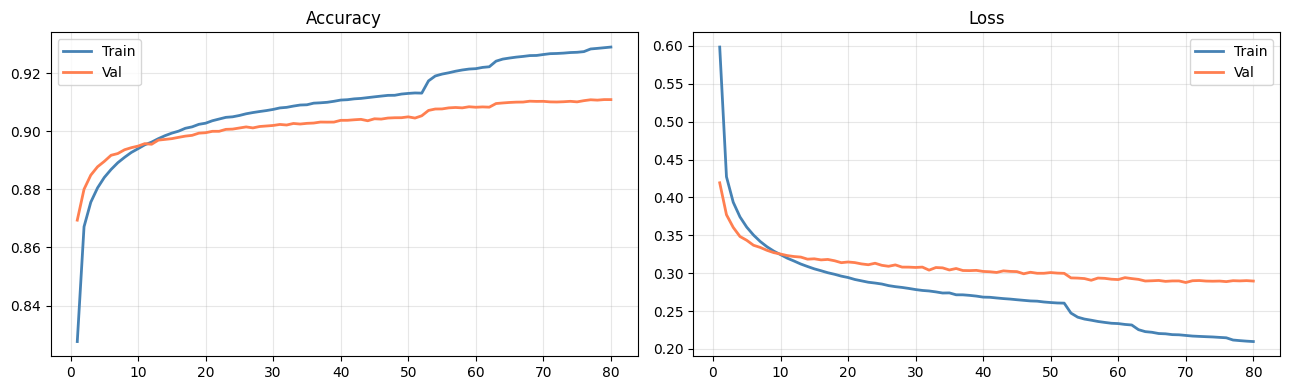

Best val accuracy: 91.09%


In [11]:
callbacks = [
    EarlyStopping(monitor='val_masked_accuracy', patience=PATIENCE,
                  restore_best_weights=True, verbose=1, mode='max'),
    ModelCheckpoint(MODEL_PATH, monitor='val_masked_accuracy',
                    save_best_only=True, verbose=1, mode='max'),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=6, min_lr=1e-5, verbose=1),
]

print(f"Training → Will save model to: {MODEL_PATH}")
print(f"Train:{X_train.shape[0]:,}  Val:{X_val.shape[0]:,}  Batch:{BATCH_SIZE}")
print("-"*60)

t0 = time.time()
history = model.fit(X_train, y_train,
                    epochs=MAX_EPOCHS, batch_size=BATCH_SIZE,
                    validation_data=(X_val, y_val),
                    callbacks=callbacks, verbose=1)
print(f"\n⏱  Training time : {(time.time()-t0)/60:.1f} min")

# ⚠ IMPORTANT: Save config to /kaggle/working/ right after training
with open(CFG_PATH, 'w') as f:
    json.dump({'max_len':MAX_LEN, 'vocab_size':VOCAB_SIZE,
               'pad_idx':PAD_IDX,  'eos_idx':EOS_IDX}, f, indent=2)
print(f"✅ Config saved → {CFG_PATH}")

# Plot curves
h = history.history
eps = range(1, len(h['masked_accuracy'])+1)
fig, axes = plt.subplots(1,2, figsize=(13,4))
axes[0].plot(eps, h['masked_accuracy'],     lw=2, label='Train', color='steelblue')
axes[0].plot(eps, h['val_masked_accuracy'], lw=2, label='Val',   color='coral')
axes[0].set_title('Accuracy'); axes[0].legend(); axes[0].grid(alpha=.3)
axes[1].plot(eps, h['loss'],     lw=2, label='Train', color='steelblue')
axes[1].plot(eps, h['val_loss'], lw=2, label='Val',   color='coral')
axes[1].set_title('Loss'); axes[1].legend(); axes[1].grid(alpha=.3)
plt.tight_layout(); plt.savefig('/kaggle/working/training_curves.png', dpi=100); plt.show()
print(f"Best val accuracy: {max(h['val_masked_accuracy'])*100:.2f}%")


## Step 8 · Neural + Snap Prediction Pipeline

In [12]:
# Reload best model (compile=False fixes Keras 3 loading error)
model = load_model(MODEL_PATH,
    custom_objects={'masked_sparse_ce': masked_sparse_ce,
                    'MaskedAccuracy'  : MaskedAccuracy},
    compile=False)
model.compile(optimizer=Adam(learning_rate=0.001),
              loss=masked_sparse_ce, metrics=[MaskedAccuracy(PAD_IDX)])
print("✅ Model loaded")

# Pool of known real names (for snap step)
known_names = sorted(set(df['Output'].tolist()))
print(f"✅ {len(known_names):,} known drug names")


✅ Model loaded
✅ 27,102 known drug names


In [13]:
def clean_raw(raw):
    """Remove trailing repeated chars: 'panadollll' → 'panadol'"""
    if not raw: return raw
    cleaned = re.sub(r'(.)\1{2,}$', r'\1', raw)
    while len(cleaned) >= 2 and cleaned[-1] == cleaned[-2]:
        cleaned = cleaned[:-1]
    return cleaned.strip()

def neural_predict(text):
    enc    = [token_to_idx.get(c, PAD_IDX) for c in list(text.lower().strip())]
    padded = pad_sequences([enc], maxlen=MAX_LEN, padding='post',
                            value=PAD_IDX, truncating='post')
    probs  = model.predict(padded, verbose=0)[0]
    idx    = np.argmax(probs, axis=-1)
    input_len   = len(text.strip())
    max_out_len = min(input_len + 3, MAX_LEN)
    chars, confs = [], []
    for t in range(max_out_len):
        tok = idx_to_token.get(int(idx[t]), '')
        p   = float(probs[t, idx[t]])
        if tok in ('<EOS>','<PAD>',''): break
        if p < 0.30 and t >= input_len: break
        chars.append(tok); confs.append(p)
    return ''.join(chars), (float(np.mean(confs)) if confs else 0.0)

def snap_to_real(query, raw_pred):
    """Find closest real drug name"""
    best_name, best_dist = raw_pred or query, 99
    for candidate in known_names:
        if abs(len(candidate) - len(query)) > 4: continue
        d_input = Levenshtein.distance(query, candidate)
        d_raw   = Levenshtein.distance(raw_pred, candidate) if raw_pred else 99
        d_min   = min(d_input, d_raw)
        if d_min < best_dist:
            best_dist, best_name = d_min, candidate
    return best_name, 1.0 / (1 + best_dist)

def predict_medicine(text):
    text = text.lower().strip()
    if not text: return '', 0.0
    raw, neural_conf = neural_predict(text)
    cleaned = clean_raw(raw)
    final, snap_score = snap_to_real(text, cleaned)
    confidence = round(0.7 * snap_score + 0.3 * neural_conf, 4)
    return final, confidence

print("✅ predict_medicine() ready")


✅ predict_medicine() ready


## Step 9 · Test Predictions (Reference Image Format)

In [14]:
# ═══ Test cases from reference image ═══
tests = [
    ("panadl",     "panadol"),
    ("asati",      "avastin"),
    ("amlodipne",  "amlodipine"),
    ("hydrcodone", "hydrocodone"),
    ("morhine",    "morphine"),
]

for i, (inp, expected) in enumerate(tests, 1):
    pred, conf = predict_medicine(inp)
    print(f"Test Case {i}:")
    print(f"Input: {inp}")
    print(f"Predicted Output: {pred}")
    print(f"Expected Output: {expected}")
    print()


Test Case 1:
Input: panadl
Predicted Output: panadol
Expected Output: panadol

Test Case 2:
Input: asati
Predicted Output: asat
Expected Output: avastin

Test Case 3:
Input: amlodipne
Predicted Output: amlodipine
Expected Output: amlodipine

Test Case 4:
Input: hydrcodone
Predicted Output: hydrocodone
Expected Output: hydrocodone

Test Case 5:
Input: morhine
Predicted Output: morphine
Expected Output: morphine



## Step 10 · Save ALL Artifacts to /kaggle/working/

⚠ This cell guarantees every file appears in the Output panel for download.


In [15]:
# Save known names file (critical for app snap step)
with open(NAMES_PATH, 'w', encoding='utf-8') as f:
    for name in known_names:
        f.write(name + '\n')
print(f"✅ Saved → {NAMES_PATH}  ({len(known_names):,} names)")

# Re-save config (in case cell was re-run)
with open(CFG_PATH, 'w') as f:
    json.dump({'max_len':MAX_LEN, 'vocab_size':VOCAB_SIZE,
               'pad_idx':PAD_IDX,  'eos_idx':EOS_IDX}, f, indent=2)
print(f"✅ Saved → {CFG_PATH}")

# ── Verify ALL 5 files exist in /kaggle/working/ ────────────────────
expected = [MODEL_PATH, T2I_PATH, I2T_PATH, CFG_PATH, NAMES_PATH]
print("\n📥 Files ready for download from Kaggle Output panel:")
print("-" * 50)
all_ok = True
for path in expected:
    ok = os.path.exists(path)
    size = f"{os.path.getsize(path)/1024:.1f} KB" if ok else "MISSING"
    mark = "✅" if ok else "❌"
    print(f"  {mark}  {os.path.basename(path):25}  {size}")
    if not ok: all_ok = False

if all_ok:
    print("\n🎉 All files saved! Go to Kaggle → Output tab to download them.")
else:
    print("\n⚠  Some files missing — re-run earlier cells")


✅ Saved → /kaggle/working/known_names.txt  (27,102 names)
✅ Saved → /kaggle/working/model_config.json

📥 Files ready for download from Kaggle Output panel:
--------------------------------------------------
  ✅  medicine_lstm.keras        18646.7 KB
  ✅  token_to_idx.json          0.3 KB
  ✅  idx_to_token.json          0.4 KB
  ✅  model_config.json          0.1 KB
  ✅  known_names.txt            214.0 KB

🎉 All files saved! Go to Kaggle → Output tab to download them.


## Step 11 · Interactive GUI

In [1]:
import ipywidgets as widgets
from IPython.display import display, HTML, clear_output

DEMOS = [("panadl","panadol"),("asati","avastin"),("amlodipne","amlodipine"),
         ("hydrcodone","hydrocodone"),("morhine","morphine"),
         ("paracetmol","paracetamol"),("asprin","aspirin"),("ibuprofn","ibuprofen"),
         ("amoxcilin","amoxicillin"),("azithromcin","azithromycin")]

def conf_color(c): return '#10B981' if c>=.85 else ('#F59E0B' if c>=.60 else '#EF4444')

header = widgets.HTML('''
<div style="background:linear-gradient(135deg,#4F46E5,#10B981);padding:22px 28px;
            border-radius:14px;margin-bottom:14px">
  <h2 style="color:#fff;margin:0;font-family:sans-serif">💊 Medicine Name Reconstruction</h2>
  <p style="color:#C7D2FE;margin:5px 0 0;font-size:13px;font-family:sans-serif">
    BiLSTM + Snap-to-Real
  </p>
</div>''')

inp_box   = widgets.Text(placeholder="Type a misspelled medicine name...",
                         layout=widgets.Layout(width='380px',height='40px'))
btn_go    = widgets.Button(description='🔍 Reconstruct',
                           layout=widgets.Layout(width='150px',height='40px'))
btn_batch = widgets.Button(description='📋 Test Cases',
                           layout=widgets.Layout(width='130px',height='40px'))
btn_go.style.button_color    = '#4F46E5'
btn_batch.style.button_color = '#0F766E'
out_res = widgets.Output()
out_bat = widgets.Output()

def on_pred(b=None):
    q = inp_box.value.strip()
    if not q: return
    p, c = predict_medicine(q)
    col = conf_color(c); bar = int(c*100)
    with out_res:
        clear_output()
        display(HTML(f'''<div style="background:#fff;border:1px solid #E2E8F0;
            border-radius:12px;padding:20px 24px;max-width:520px;font-family:sans-serif;margin-top:12px">
          <div style="display:flex;gap:18px;align-items:center;margin-bottom:14px">
            <div><div style="font-size:11px;color:#94A3B8;text-transform:uppercase">Input</div>
                 <div style="font-size:17px;color:#475569">{q}</div></div>
            <div style="font-size:24px;color:#CBD5E1">→</div>
            <div><div style="font-size:11px;color:#94A3B8;text-transform:uppercase">Corrected</div>
                 <div style="font-size:28px;font-weight:700;color:#4F46E5">{p}</div></div>
          </div>
          <div style="font-size:12px;color:#64748B">Confidence {c*100:.1f}%</div>
          <div style="background:#E2E8F0;border-radius:8px;height:12px;overflow:hidden;margin-top:4px">
            <div style="width:{bar}%;background:{col};height:100%;border-radius:8px"></div>
          </div></div>'''))

def on_batch(b):
    with out_bat:
        clear_output()
        blocks = []
        for i, (inp, exp) in enumerate(DEMOS, 1):
            p, c = predict_medicine(inp)
            ok = '<span style="color:#34D399;margin-left:6px">✓</span>' if p==exp else '<span style="color:#F87171;margin-left:6px">✗</span>'
            blocks.append(f'''<div style="padding:14px 16px;border-left:4px solid #4F46E5;
                background:#0F172A;color:#E2E8F0;margin-bottom:8px;border-radius:0 8px 8px 0;
                font-family:monospace">
                <div style="font-weight:700;color:#10B981;font-size:13px;margin-bottom:5px">Test Case {i}:</div>
                <div style="font-size:13px;line-height:1.75">
                  Input: <b style="color:#F0F9FF">{inp}</b><br>
                  Predicted Output: <b style="color:#F0F9FF">{p}</b><br>
                  Expected Output: <b style="color:#F0F9FF">{exp}</b>{ok}
                </div></div>''')
        display(HTML('<div style="max-width:560px;margin-top:12px">' + ''.join(blocks) + '</div>'))

btn_go.on_click(on_pred); btn_batch.on_click(on_batch)
inp_box.on_submit(on_pred)

display(widgets.VBox([header,
    widgets.HBox([inp_box, btn_go, btn_batch],
                  layout=widgets.Layout(gap='10px', align_items='center', margin='0 0 12px 0')),
    out_res, out_bat
], layout=widgets.Layout(max_width='620px')))


/tmp/ipykernel_55/2153215385.py:71: DeprecationWarning: on_submit is deprecated. Instead, set the .continuous_update attribute to False and observe the value changing with: mywidget.observe(callback, 'value').
  inp_box.on_submit(on_pred)


---
## Step 12 · Reload Model (Skip Retraining)

Run this cell + Step 8 + Step 9 to reuse saved model. Uncomment the block.


In [17]:
# import json, re, numpy as np, tensorflow as tf, Levenshtein
# from tensorflow.keras.models import load_model
# from tensorflow.keras.optimizers import Adam
# from tensorflow.keras.preprocessing.sequence import pad_sequences
#
# MODEL_PATH = '/kaggle/working/medicine_lstm.keras'
# T2I_PATH   = '/kaggle/working/token_to_idx.json'
# I2T_PATH   = '/kaggle/working/idx_to_token.json'
# CFG_PATH   = '/kaggle/working/model_config.json'
# NAMES_PATH = '/kaggle/working/known_names.txt'
#
# with open(T2I_PATH) as f: token_to_idx = json.load(f)
# with open(I2T_PATH) as f: idx_to_token = {int(k):v for k,v in json.load(f).items()}
# with open(CFG_PATH) as f: cfg = json.load(f)
# MAX_LEN = cfg['max_len']; PAD_IDX = cfg['pad_idx']
# EOS_IDX = cfg['eos_idx']; VOCAB_SIZE = cfg['vocab_size']
#
# with open(NAMES_PATH) as f:
#     known_names = sorted(set(line.strip() for line in f if line.strip()))
#
# @tf.function
# def masked_sparse_ce(y_true, y_pred):
#     y_true = tf.cast(y_true, tf.int32)
#     loss = tf.keras.losses.sparse_categorical_crossentropy(y_true, y_pred)
#     mask = tf.cast(tf.not_equal(y_true, PAD_IDX), tf.float32)
#     return tf.reduce_sum(loss * mask) / (tf.reduce_sum(mask) + 1e-8)
#
# class MaskedAccuracy(tf.keras.metrics.Metric):
#     def __init__(self, pad_idx=PAD_IDX, name='masked_accuracy', **kw):
#         super().__init__(name=name, **kw)
#         self.pad_idx=pad_idx
#         self.correct=self.add_weight(name='correct',initializer='zeros')
#         self.total=self.add_weight(name='total',initializer='zeros')
#     def update_state(self,yt,yp,sw=None):
#         yt=tf.cast(tf.reshape(yt,[-1]),tf.int32)
#         yp=tf.cast(tf.argmax(yp,axis=-1),tf.int32);yp=tf.reshape(yp,[-1])
#         m=tf.not_equal(yt,self.pad_idx)
#         self.correct.assign_add(tf.reduce_sum(tf.cast(tf.equal(tf.boolean_mask(yt,m),tf.boolean_mask(yp,m)),tf.float32)))
#         self.total.assign_add(tf.cast(tf.reduce_sum(tf.cast(m,tf.int32)),tf.float32))
#     def result(self): return self.correct/(self.total+1e-8)
#     def reset_state(self): self.correct.assign(0.);self.total.assign(0.)
#
# model = load_model(MODEL_PATH,
#     custom_objects={'masked_sparse_ce':masked_sparse_ce,'MaskedAccuracy':MaskedAccuracy},
#     compile=False)
# model.compile(optimizer=Adam(learning_rate=0.001),
#               loss=masked_sparse_ce, metrics=[MaskedAccuracy(PAD_IDX)])
# print(f'✅ Reloaded vocab={VOCAB_SIZE} max_len={MAX_LEN}')
# print(f'✅ {len(known_names):,} known names')
# print('Now run Step 8 second cell (prediction functions), then Step 9/11.')


In [1]:
import json, re, numpy as np, tensorflow as tf, Levenshtein
from tensorflow.keras.models import load_model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.sequence import pad_sequences

MODEL_PATH = '/kaggle/working/medicine_lstm.keras'
T2I_PATH   = '/kaggle/working/token_to_idx.json'
I2T_PATH   = '/kaggle/working/idx_to_token.json'
CFG_PATH   = '/kaggle/working/model_config.json'
NAMES_PATH = '/kaggle/working/known_names.txt'

with open(T2I_PATH) as f: token_to_idx = json.load(f)
with open(I2T_PATH) as f: idx_to_token = {int(k):v for k,v in json.load(f).items()}
with open(CFG_PATH) as f: cfg = json.load(f)
MAX_LEN = cfg['max_len']; PAD_IDX = cfg['pad_idx']
EOS_IDX = cfg['eos_idx']; VOCAB_SIZE = cfg['vocab_size']

with open(NAMES_PATH) as f:
    known_names = sorted(set(line.strip() for line in f if line.strip()))

@tf.function
def masked_sparse_ce(y_true, y_pred):
    y_true = tf.cast(y_true, tf.int32)
    loss = tf.keras.losses.sparse_categorical_crossentropy(y_true, y_pred)
    mask = tf.cast(tf.not_equal(y_true, PAD_IDX), tf.float32)
    return tf.reduce_sum(loss * mask) / (tf.reduce_sum(mask) + 1e-8)

class MaskedAccuracy(tf.keras.metrics.Metric):
    def __init__(self, pad_idx=PAD_IDX, name='masked_accuracy', **kw):
        super().__init__(name=name, **kw)
        self.pad_idx=pad_idx
        self.correct=self.add_weight(name='correct',initializer='zeros')
        self.total=self.add_weight(name='total',initializer='zeros')
    def update_state(self,yt,yp,sw=None):
        yt=tf.cast(tf.reshape(yt,[-1]),tf.int32)
        yp=tf.cast(tf.argmax(yp,axis=-1),tf.int32);yp=tf.reshape(yp,[-1])
        m=tf.not_equal(yt,self.pad_idx)
        self.correct.assign_add(tf.reduce_sum(tf.cast(tf.equal(tf.boolean_mask(yt,m),tf.boolean_mask(yp,m)),tf.float32)))
        self.total.assign_add(tf.cast(tf.reduce_sum(tf.cast(m,tf.int32)),tf.float32))
    def result(self): return self.correct/(self.total+1e-8)
    def reset_state(self): self.correct.assign(0.);self.total.assign(0.)

model = load_model(MODEL_PATH,
    custom_objects={'masked_sparse_ce':masked_sparse_ce,'MaskedAccuracy':MaskedAccuracy},
    compile=False)
model.compile(optimizer=Adam(learning_rate=0.001),
              loss=masked_sparse_ce, metrics=[MaskedAccuracy(PAD_IDX)])
print(f'✅ Reloaded vocab={VOCAB_SIZE} max_len={MAX_LEN}')
print(f'✅ {len(known_names):,} known names')
print('Now run Step 8 second cell (prediction functions), then Step 9/11.')


2026-04-23 01:36:23.681060: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1776908183.937642      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1776908184.008191      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1776908184.542481      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776908184.542526      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776908184.542529      55 computation_placer.cc:177] computation placer alr

ModuleNotFoundError: No module named 'Levenshtein'